# 17 — Loan-Level Stress Transmission

## Passing the scenario through individual loans

The scenario design is complete. This notebook shows how the shocks change PD, LGD, EAD and RWA on the same loans before results are aggregated.

The capital impact can be understood only after the scenario has passed through loan-level risk drivers. This separates the cause of stress from the final ratio movement.

### How shocks change loan calculations

| Term | Simple meaning |
|---|---|
| Transmission | the path from a scenario shock to a loan calculation |
| Base | the unshocked calculation |
| Adverse | the moderate synthetic stress |
| Severe | the stronger synthetic stress |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


## The same loans under three scenarios

The engine reruns classification, EAD, risk weights, PD, LGD and IRB capital after applying each scenario. The comparison therefore uses the same exposure IDs under three conditions.

In [2]:
scenario_loans = {
    name: pd.read_csv(ROOT / f"data/processed/scenario_{name}.csv.gz", low_memory=False)
    for name in ["base", "adverse", "severe"]
}
transmission_summary = []
for name, frame in scenario_loans.items():
    transmission_summary.append({
        "Scenario": name, "EAD (INR crore)": frame["ead_pre_crm"].sum() / CRORE,
        "Expected loss (INR crore)": frame["expected_loss_amount"].sum() / CRORE,
        "SA RWA (INR crore)": frame["sa_rwa"].sum() / CRORE,
        "IRB RWA (INR crore)": frame["irb_rwa"].sum() / CRORE,
    })
transmission_summary = pd.DataFrame(transmission_summary).set_index("Scenario").reindex(["base", "adverse", "severe"])
display(transmission_summary)

,EAD (INR crore),Expected loss (INR crore),SA RWA (INR crore),IRB RWA (INR crore)
Scenario,,,,
base,700735.464834,11753.820884,405323.359431,583349.232898
adverse,746518.283436,16773.183072,438399.649407,769539.139744
severe,810207.196957,24945.246357,484304.755279,988975.097136


EAD can rise when unused commitments are drawn. Expected loss rises when PD, LGD or EAD increases. SA RWA changes mainly through EAD and mortgage LTV bands, while IRB RWA also responds to PD, LGD, correlation and maturity mechanics.

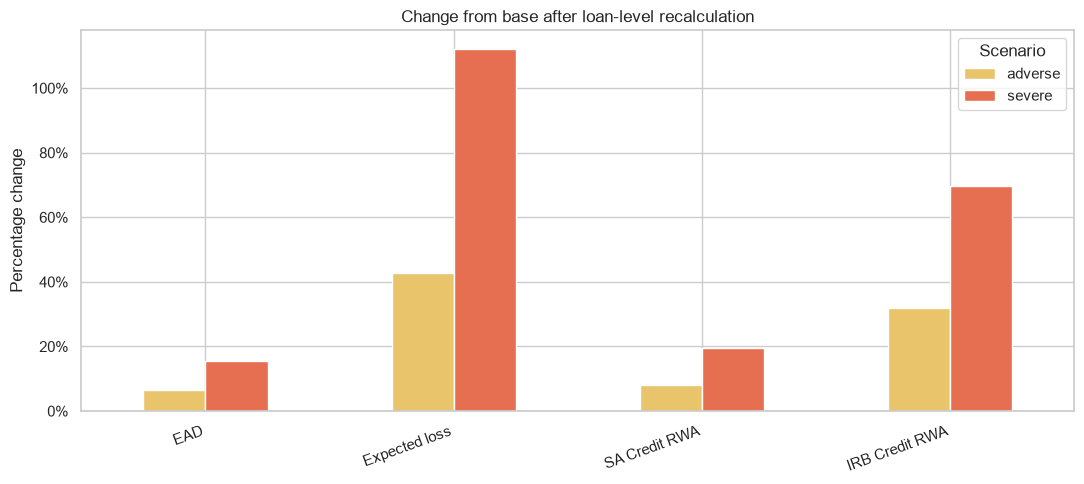

In [3]:
change_from_base = transmission_summary.div(transmission_summary.loc["base"]).sub(1).drop(index="base")
change_from_base.columns = ["EAD", "Expected loss", "SA Credit RWA", "IRB Credit RWA"]
change_from_base.T.plot.bar(figsize=(11, 5), color=[COLORS[3], COLORS[5]], title="Change from base after loan-level recalculation")
plt.ylabel("Percentage change")
plt.xlabel("")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Percentage change keeps EAD, expected loss and the two RWA approaches readable on one scale. The chart shows sensitivity rather than absolute portfolio size.

## One revolving loan before and after stress

A single common exposure makes the transmission concrete. Additional utilisation changes EAD; the PD and LGD shocks then change expected loss and IRB RWA.

In [4]:
candidate = scenario_loans["base"].loc[lambda frame: frame["undrawn_amount"].gt(0) & frame["default_flag"].eq(0), "exposure_id"].iloc[0]
trace = []
for name, frame in scenario_loans.items():
    row = frame.loc[frame["exposure_id"].eq(candidate)].iloc[0]
    trace.append([name, row["pd_regulatory"], row["lgd_regulatory"], row["ead_pre_crm"] / CRORE, row["ead_irb"] / CRORE, row["expected_loss_amount"] / CRORE, row["sa_rwa"] / CRORE, row["irb_rwa"] / CRORE])
trace = pd.DataFrame(trace, columns=["Scenario", "PD", "LGD", "SA EAD (INR crore)", "IRB EAD (INR crore)", "Expected loss (INR crore)", "SA RWA (INR crore)", "IRB RWA (INR crore)"])
display(trace.style.format({"PD": "{:.2%}", "LGD": "{:.2%}"}))

,Scenario,PD,LGD,SA EAD (INR crore),IRB EAD (INR crore),Expected loss (INR crore),SA RWA (INR crore),IRB RWA (INR crore)
0,base,0.05%,74.38%,335.443255,372.638892,0.138577,67.088651,196.179145
1,adverse,0.05%,85.13%,364.345126,394.315295,0.167843,72.869025,237.610647
2,severe,0.05%,96.05%,407.697933,426.829900,0.204987,81.539587,290.193565


This trace shows why stress is not a single top-level percentage applied to total RWA. Each affected risk driver is recalculated before the bank-level capital ratios are produced.